# Simulacion de agente en el tablero 


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd
import numpy as np
import sys
from mesa.batchrunner import batch_run

sns.set()
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

from models.flashpoint_model import FlashPoint


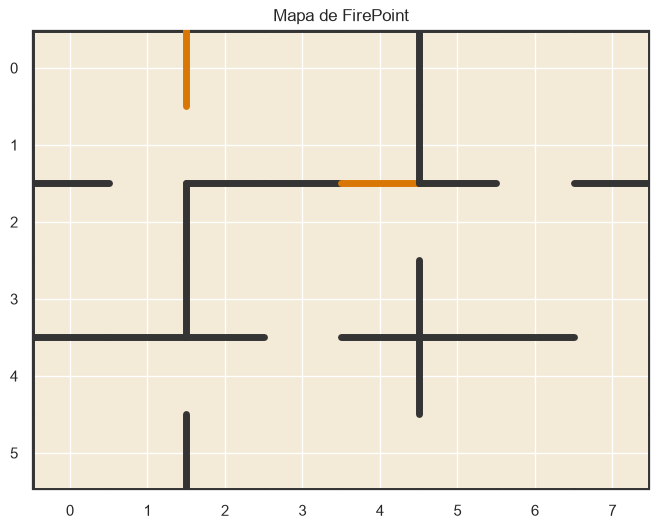

In [3]:
def dibujar_mapa(paredes_verticales, paredes_horizontales, alto, ancho, titulo="Mapa de FirePoint"):
    PARED, PUERTA_CERRADA, PUERTA_ABIERTA = 1, 2, 3

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(-0.5, ancho - 0.5)
    ax.set_ylim(alto - 0.5, -0.5)
    ax.set_xticks(range(ancho))
    ax.set_yticks(range(alto))
    ax.set_facecolor("#f3ead8")

    for limite_fila in range(alto + 1):
        for columna in range(ancho):
            estado = paredes_horizontales[limite_fila, columna]
            x0, x1, y = columna - 0.5, columna + 0.5, limite_fila - 0.5
            if estado == PARED:
                ax.plot([x0, x1], [y, y], color="#343434", linewidth=5)
            elif estado == PUERTA_CERRADA:
                ax.plot([x0, x1], [y, y], color="#d97706", linewidth=5)
            elif estado == PUERTA_ABIERTA:
                ax.plot([x0, x1], [y, y], color="#16a34a", linewidth=3, linestyle="--")

    for fila in range(alto):
        for limite_columna in range(ancho + 1):
            estado = paredes_verticales[fila, limite_columna]
            x, y0, y1 = limite_columna - 0.5, fila - 0.5, fila + 0.5
            if estado == PARED:
                ax.plot([x, x], [y0, y1], color="#343434", linewidth=5)
            elif estado == PUERTA_CERRADA:
                ax.plot([x, x], [y0, y1], color="#d97706", linewidth=5)
            elif estado == PUERTA_ABIERTA:
                ax.plot([x, x], [y0, y1], color="#16a34a", linewidth=3, linestyle="--")

    ax.set_title(titulo)
    plt.show()

modelo_ejemplo = FlashPoint()
dibujar_mapa(modelo_ejemplo.paredes_verticales, modelo_ejemplo.paredes_horizontales,
             modelo_ejemplo.height, modelo_ejemplo.width)


In [4]:
params = {
    "num_agentes": [1, 2, 3, 4, 5, 6],
    "estrategia": ["cercano", "apagafuegos", "aleatorio"],
}

MAX_STEPS = 60

rng = np.random.default_rng(42)
rng_values = rng.integers(0, sys.maxsize, size=(5,))

results = batch_run(
    FlashPoint,
    parameters=params,
    rng=rng_values.tolist(),
    max_steps=MAX_STEPS,
    number_processes=1,
    data_collection_period=-1,
    display_progress=True,
)

df = pd.DataFrame(results)
df.info()


  0%|          | 0/90 [00:00<?, ?it/s]

UnboundLocalError: cannot access local variable 'dano_total' where it is not associated with a value

In [13]:
resumen_turnos = (
    df.groupby(["RunId", "iteration", "num_agentes", "estrategia"])["Turno"]
    .max()
    .reset_index()
)

promedio_turnos = (
    resumen_turnos.groupby(["num_agentes", "estrategia"])["Turno"]
    .mean()
    .reset_index()
)

promedio_turnos


,num_agentes,estrategia,Turno
0,1,aleatorio,60.0
1,1,apagafuegos,60.0
2,1,cercano,60.0
3,2,aleatorio,60.0
4,2,apagafuegos,60.0
5,2,cercano,60.0
6,3,aleatorio,60.0
7,3,apagafuegos,60.0
8,3,cercano,60.0


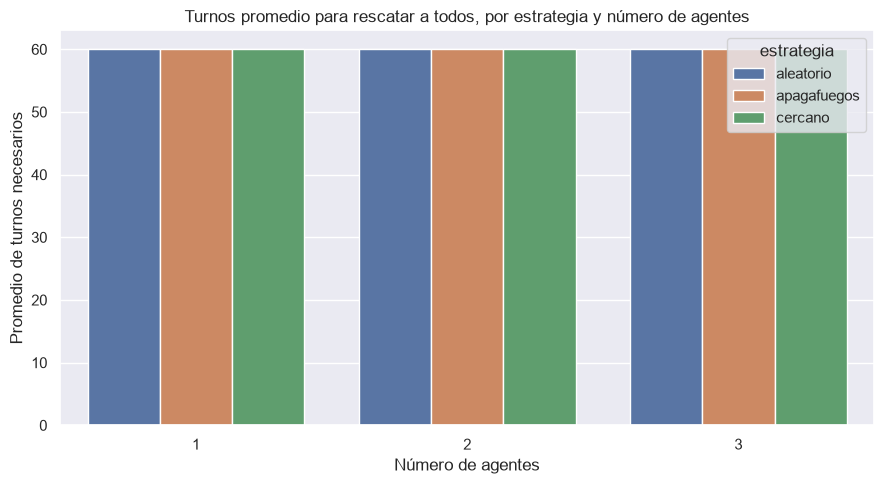

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=promedio_turnos, x="num_agentes", y="Turno", hue="estrategia")
plt.xlabel("Número de agentes")
plt.ylabel("Promedio de turnos necesarios")
plt.title("Turnos promedio para rescatar a todos, por estrategia y número de agentes")
plt.tight_layout()
plt.show()


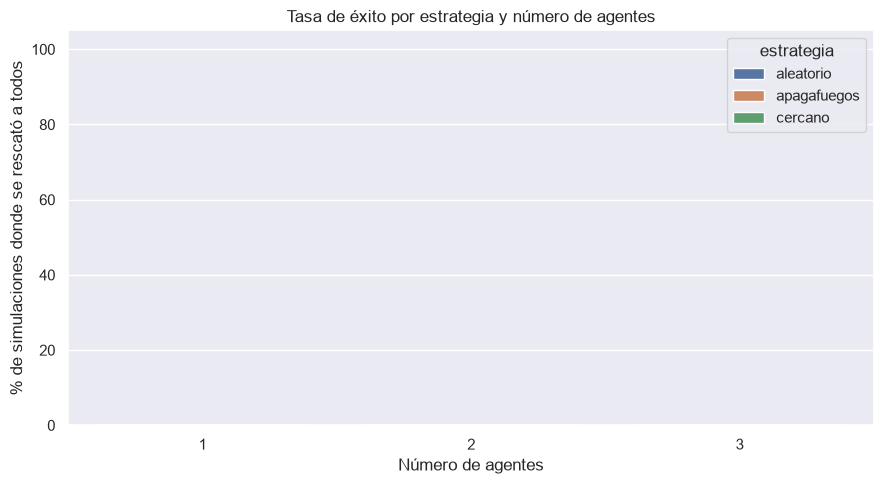

In [15]:
tasa_exito = (
    df.groupby(["RunId", "iteration", "num_agentes", "estrategia"])["Terminado"]
    .max()
    .reset_index()
)

tasa_exito_prom = (
    tasa_exito.groupby(["num_agentes", "estrategia"])["Terminado"]
    .mean()
    .reset_index()
)
tasa_exito_prom["Terminado"] *= 100  # a porcentaje

plt.figure(figsize=(9, 5))
sns.barplot(data=tasa_exito_prom, x="num_agentes", y="Terminado", hue="estrategia")
plt.xlabel("Número de agentes")
plt.ylabel("% de simulaciones donde se rescató a todos")
plt.title("Tasa de éxito por estrategia y número de agentes")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


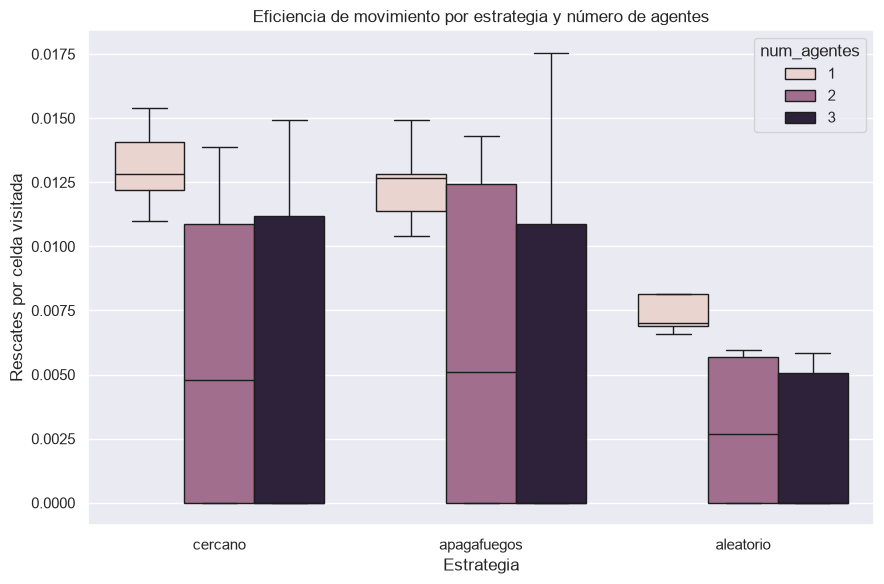

In [16]:
eficiencia = (
    df.dropna(subset=["AgentID"])
    .groupby(["RunId", "iteration", "num_agentes", "estrategia", "AgentID"])
    .agg(Rescates=("Rescates", "max"), CeldasVisitadas=("CeldasVisitadas", "max"))
    .reset_index()
)
eficiencia["RescatesPorCelda"] = eficiencia["Rescates"] / eficiencia["CeldasVisitadas"]

plt.figure(figsize=(9, 6))
sns.boxplot(data=eficiencia, x="estrategia", y="RescatesPorCelda", hue="num_agentes")
plt.xlabel("Estrategia")
plt.ylabel("Rescates por celda visitada")
plt.title("Eficiencia de movimiento por estrategia y número de agentes")
plt.tight_layout()
plt.show()


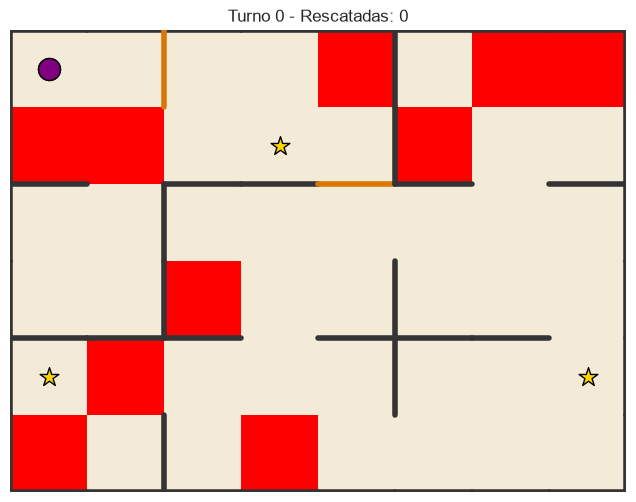

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import numpy as np

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

from models.flashpoint_model import FlashPoint

# --- Correr la simulación guardando TODO el historial, incluyendo paredes ---
model = FlashPoint(num_agentes=2, estrategia="cercano")

N_TURNOS = 15
historial_fuego = [model.fuego.copy()]
historial_pois = [model.pois.copy()]
historial_pv = [model.paredes_verticales.copy()]
historial_ph = [model.paredes_horizontales.copy()]
historial_agentes = [[(b.fila, b.columna) for b in model.agents]]
historial_rescatadas = [model.victimas_rescatadas]

for _ in range(N_TURNOS):
    model.step()
    historial_fuego.append(model.fuego.copy())
    historial_pois.append(model.pois.copy())
    historial_pv.append(model.paredes_verticales.copy())
    historial_ph.append(model.paredes_horizontales.copy())
    historial_agentes.append([(b.fila, b.columna) for b in model.agents])
    historial_rescatadas.append(model.victimas_rescatadas)

# --- Animación completa: fuego + POIs + paredes/puertas + agentes ---
ALTO, ANCHO = model.height, model.width
PARED, PUERTA_CERRADA, PUERTA_ABIERTA = 1, 2, 3
fuego_cmap = ListedColormap(["#f3ead8", "gray", "red"])
colores_agentes = ["blue", "purple", "teal", "brown"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xticks([]); ax.set_yticks([])

patch_fuego = ax.imshow(historial_fuego[0], cmap=fuego_cmap, vmin=0, vmax=2,
                         extent=(-0.5, ANCHO - 0.5, ALTO - 0.5, -0.5))
puntos_pois = ax.scatter([], [], color="gold", s=200, marker="*", edgecolors="black", zorder=4)
puntos_agentes = [
    ax.scatter([], [], color=colores_agentes[i % len(colores_agentes)], s=250, edgecolors="black", zorder=5)
    for i in range(len(historial_agentes[0]))
]
lineas_paredes = []
titulo = ax.set_title("Turno 0")

def dibujar_paredes(pv, ph):
    for l in lineas_paredes:
        l.remove()
    lineas_paredes.clear()
    for lf in range(ALTO + 1):
        for c in range(ANCHO):
            estado = ph[lf, c]
            x0, x1, y = c - 0.5, c + 0.5, lf - 0.5
            if estado == PARED:
                lineas_paredes.append(ax.plot([x0, x1], [y, y], color="#343434", linewidth=4, zorder=3)[0])
            elif estado == PUERTA_CERRADA:
                lineas_paredes.append(ax.plot([x0, x1], [y, y], color="#d97706", linewidth=4, zorder=3)[0])
            elif estado == PUERTA_ABIERTA:
                lineas_paredes.append(ax.plot([x0, x1], [y, y], color="#16a34a", linewidth=3, linestyle="--", zorder=3)[0])
    for f in range(ALTO):
        for lc in range(ANCHO + 1):
            estado = pv[f, lc]
            x, y0, y1 = lc - 0.5, f - 0.5, f + 0.5
            if estado == PARED:
                lineas_paredes.append(ax.plot([x, x], [y0, y1], color="#343434", linewidth=4, zorder=3)[0])
            elif estado == PUERTA_CERRADA:
                lineas_paredes.append(ax.plot([x, x], [y0, y1], color="#d97706", linewidth=4, zorder=3)[0])
            elif estado == PUERTA_ABIERTA:
                lineas_paredes.append(ax.plot([x, x], [y0, y1], color="#16a34a", linewidth=3, linestyle="--", zorder=3)[0])

def animate(i):
    patch_fuego.set_data(historial_fuego[i])
    dibujar_paredes(historial_pv[i], historial_ph[i])

    filas_poi, cols_poi = (historial_pois[i] == 2).nonzero()
    offsets = list(zip(cols_poi, filas_poi))
    if len(offsets) == 0:
        offsets = np.empty((0, 2))
    puntos_pois.set_offsets(offsets)

    for idx, (fila_a, col_a) in enumerate(historial_agentes[i]):
        puntos_agentes[idx].set_offsets([[col_a, fila_a]])

    titulo.set_text(f"Turno {i} - Rescatadas: {historial_rescatadas[i]}")
    return [patch_fuego, puntos_pois, titulo, *puntos_agentes, *lineas_paredes]

anim = animation.FuncAnimation(fig, animate, frames=len(historial_fuego), interval=700)
anim